# Why Seaborn?

 - provide a layer of abstraction hence simple to use
 - better aesthetics
 - more graphs included

# Seaborn Roadmap

Types of Functions
- Figure Level
- Axis Level

Main Classification
- Relational plot
- Distribution plot
- categorical plot
- regression plot
- Matrix plot
- Multiplots

https://seaborn.pydata.org/api.html

### 1. Relational Plot

- to see the statistical relation between 2 or more variables.
- Bivariate Analysis

Plots under this section

- scatterplot
- lineplot

In [1]:
import seaborn as sns
import sys
import matplotlib.pyplot as plt 
try:
    import plotly.express as px
except ImportError:
    !{sys.executable} -m pip install plotly
    import plotly.express as px

In [2]:
tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

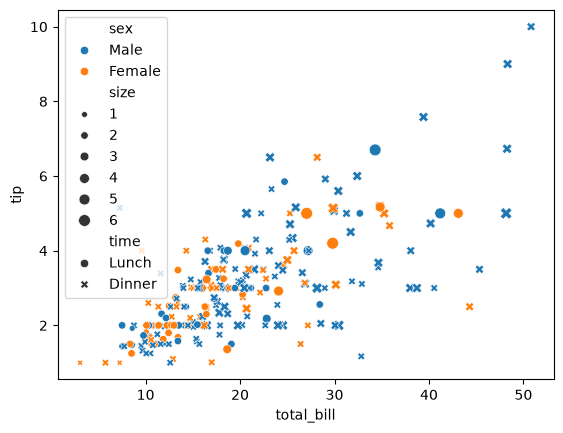

In [3]:
# scatter plot -> axis level function
sns.scatterplot(data=tips,x='total_bill',y='tip', hue='sex', style='time', size='size')

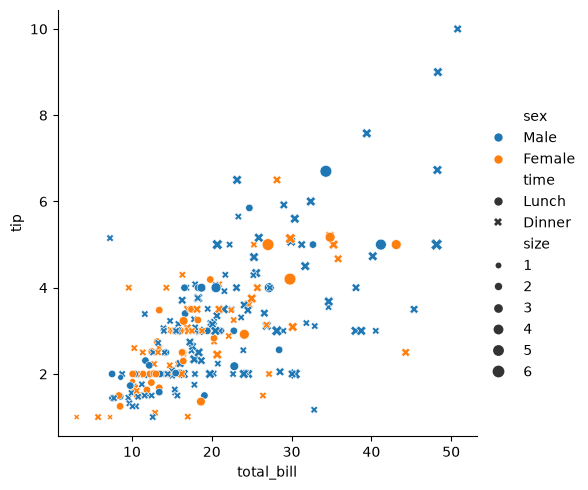

In [4]:
# relplot -> figure level -> square shape
sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter', hue='sex', style='time', size='size')

In [5]:
# scatter using relplot -> size and hue -> style semantics

In [6]:
# line plot -> time-series data best use case

gap = px.data.gapminder()
gap

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
...,...,...,...,...,...,...,...,...
1699,Zimbabwe,Africa,1987,62.351,9216418,706.157306,ZWE,716
1700,Zimbabwe,Africa,1992,60.377,10704340,693.420786,ZWE,716
1701,Zimbabwe,Africa,1997,46.809,11404948,792.449960,ZWE,716
1702,Zimbabwe,Africa,2002,39.989,11926563,672.038623,ZWE,716


In [7]:
temp_df = gap[gap['country'] == 'India']

<Axes: xlabel='year', ylabel='lifeExp'>

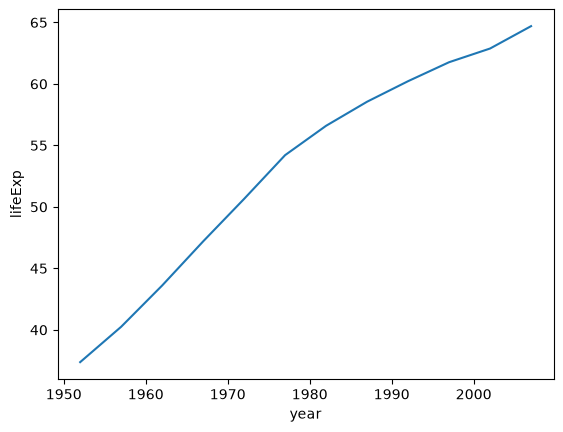

In [8]:
# axes level
sns.lineplot(data=temp_df,x='year',y='lifeExp')

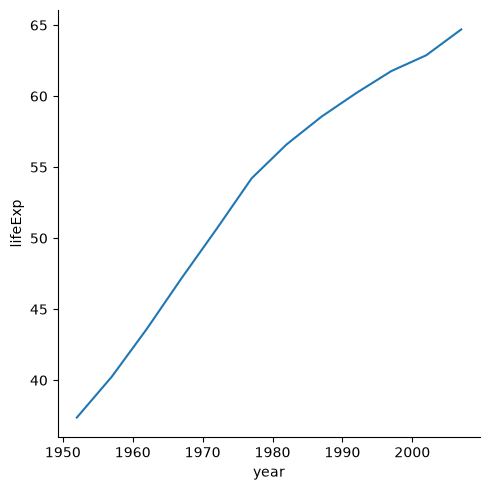

In [9]:
sns.relplot(data=temp_df,x='year',y='lifeExp',kind='line')

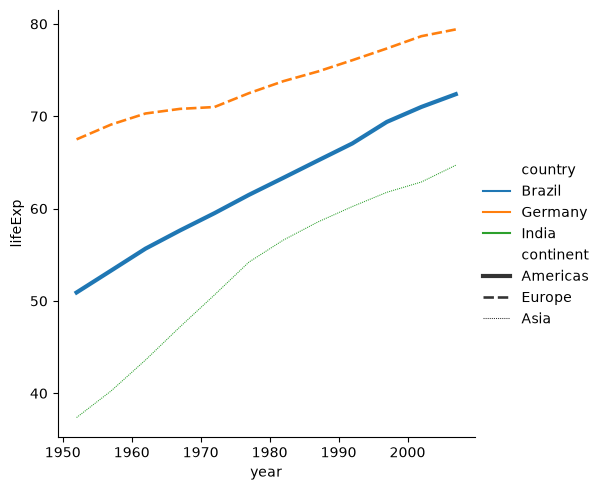

In [10]:
# hue -> style

temp_df = gap[gap['country'].isin(['India','Brazil','Germany'])]

sns.relplot(kind='line',data=temp_df,x='year',y='lifeExp',hue='country',style='continent',size='continent')

<Axes: xlabel='year', ylabel='lifeExp'>

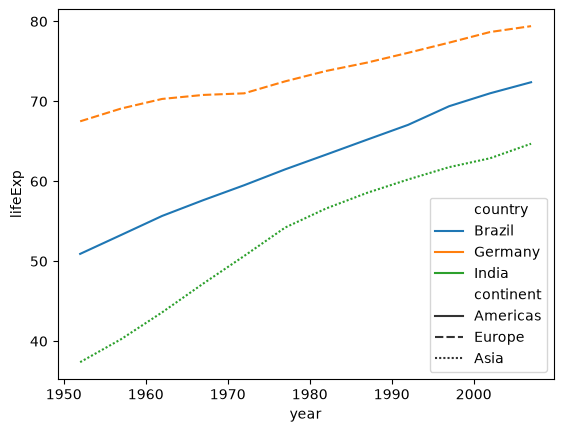

In [11]:
sns.lineplot(data=temp_df,x='year',y='lifeExp',hue='country',style='continent')

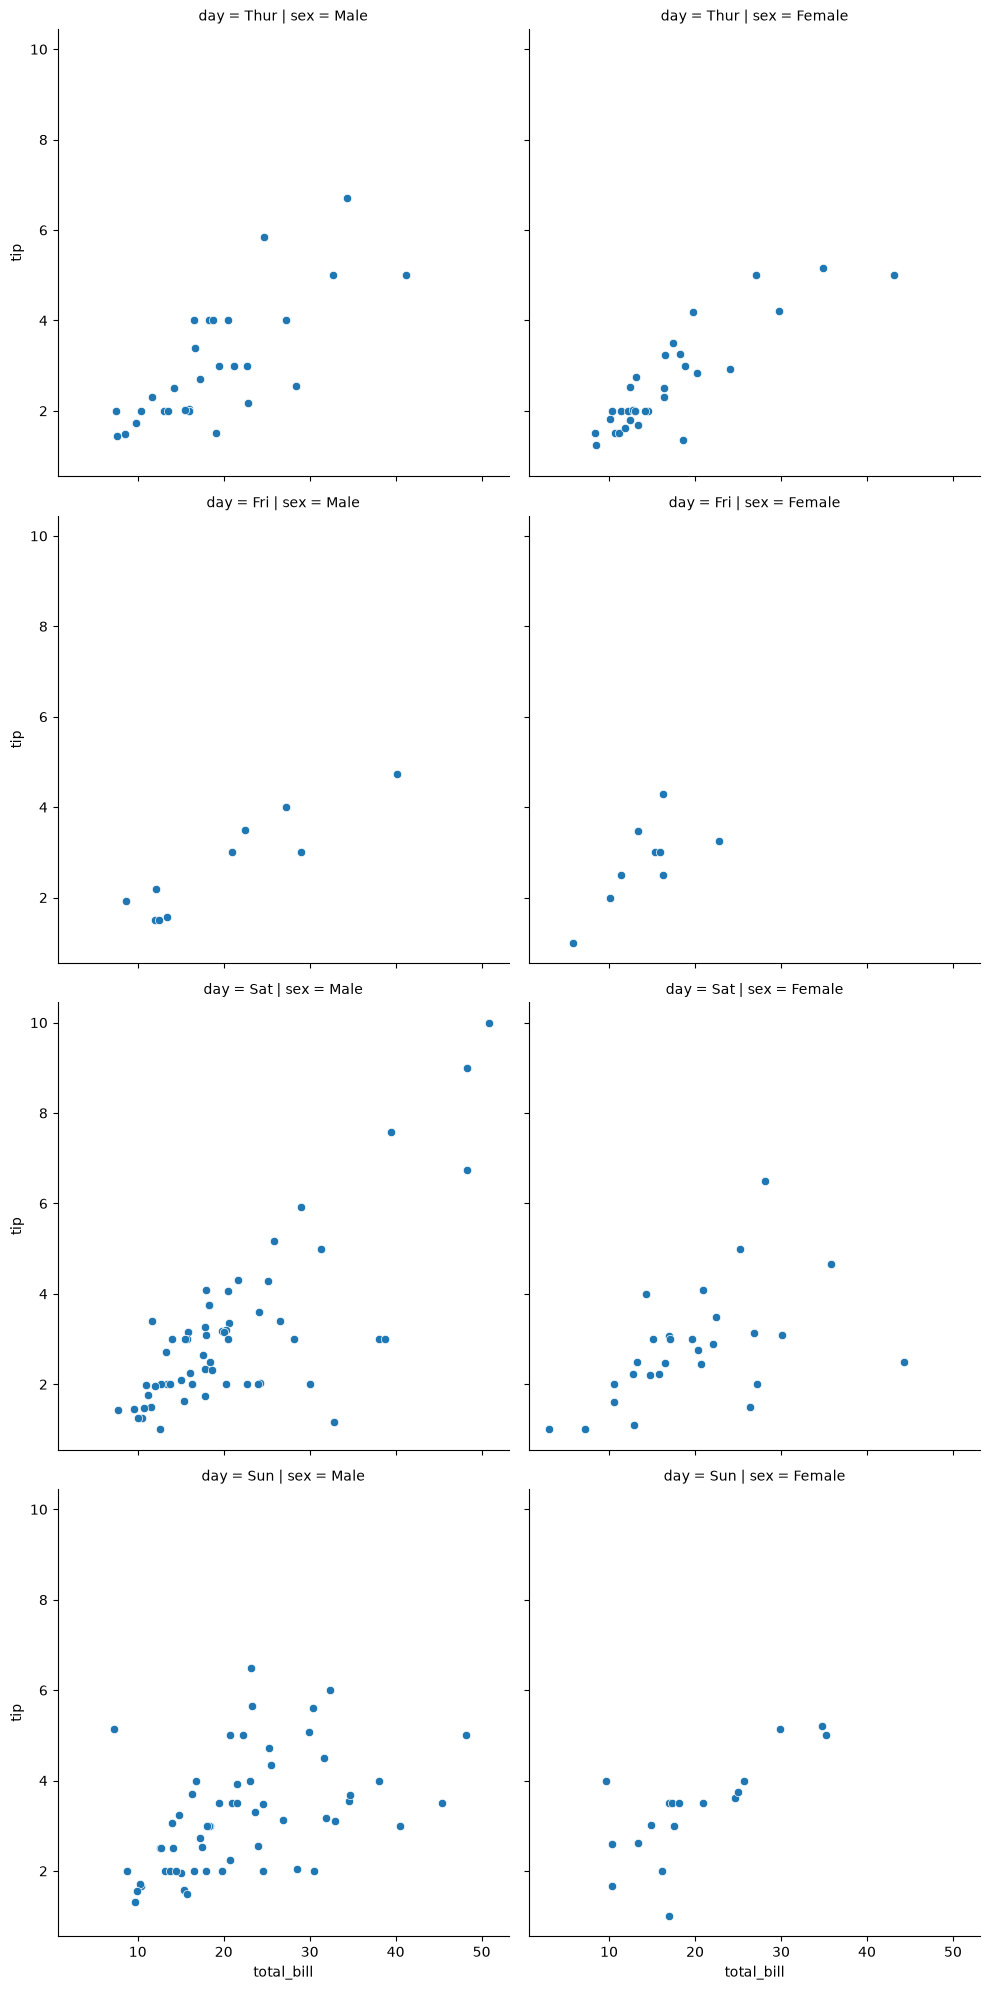

In [12]:
# facet plot -> only work with figure level function/not with axes level function

sns.relplot(data=tips,x='total_bill',y='tip',kind='scatter',col='sex',row='day')

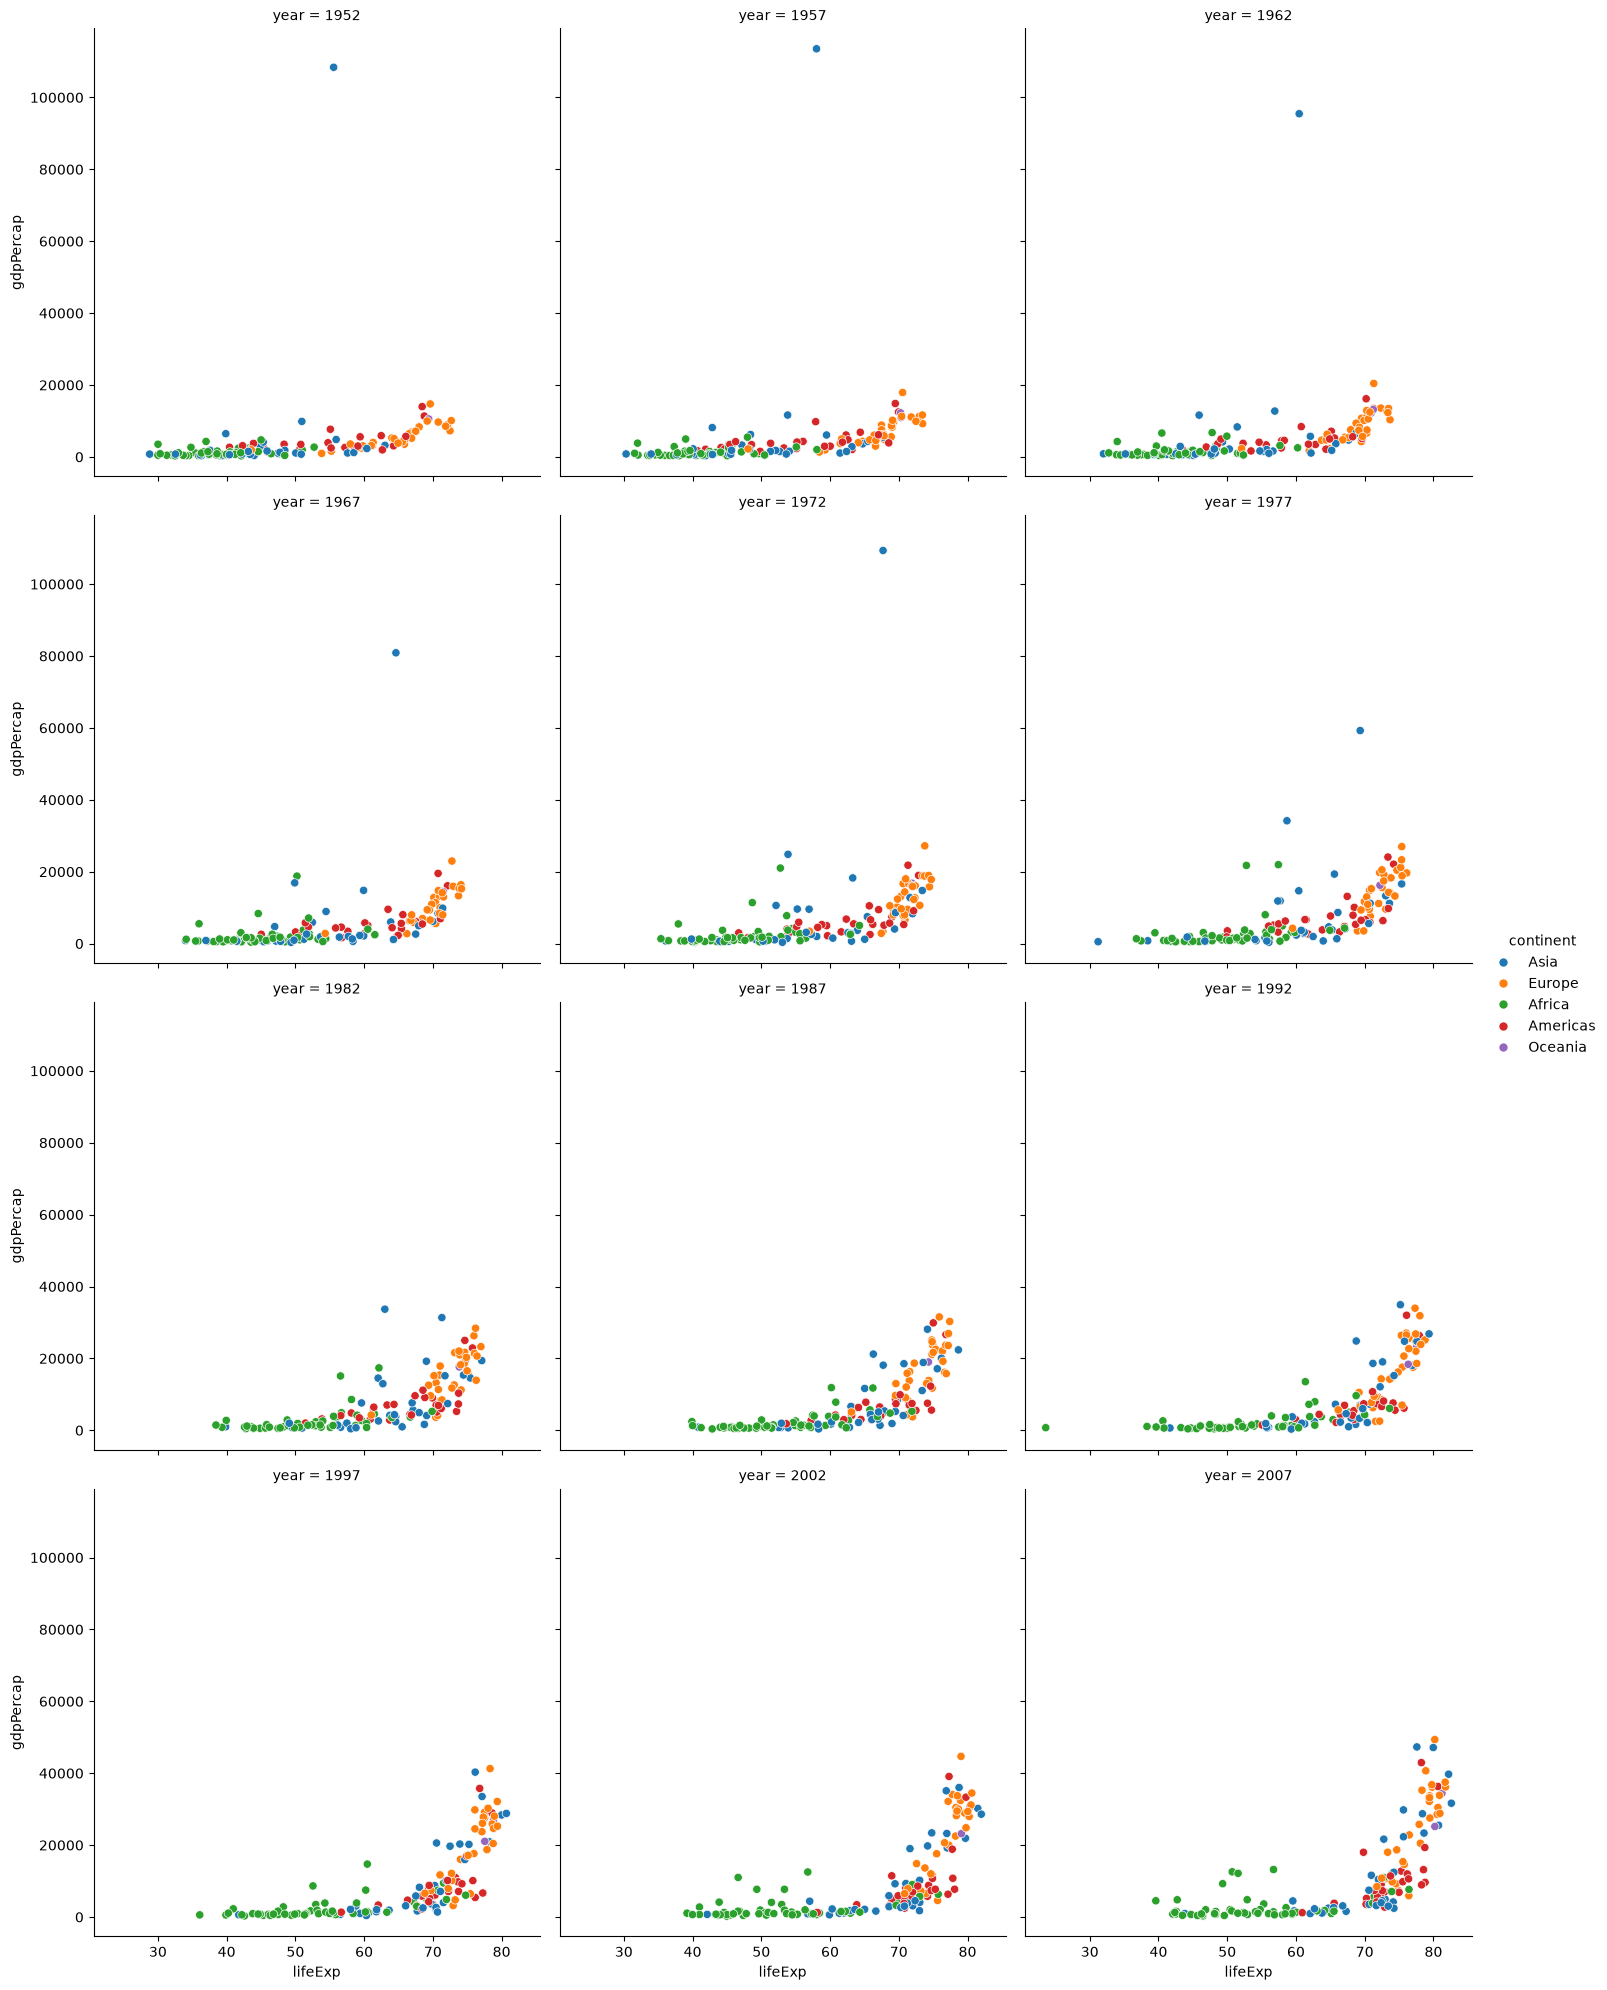

In [13]:
# col wrap

sns.relplot(data=gap,x='lifeExp',y='gdpPercap',kind='scatter',col='year',col_wrap=3, hue='continent')

### 2. Distribution Plots

- used for univariate analysis
- used to find out the distribution
- Range of the observation
- Central Tendency
- is the data bimodal?
- Are there outliers?

Plots under distribution plot

- histplot
- kdeplot
- rugplot

In [14]:
# figure-level -> displot
# axes-level -> hisplot -> kdeplot -> rugplot

<Axes: xlabel='total_bill', ylabel='Count'>

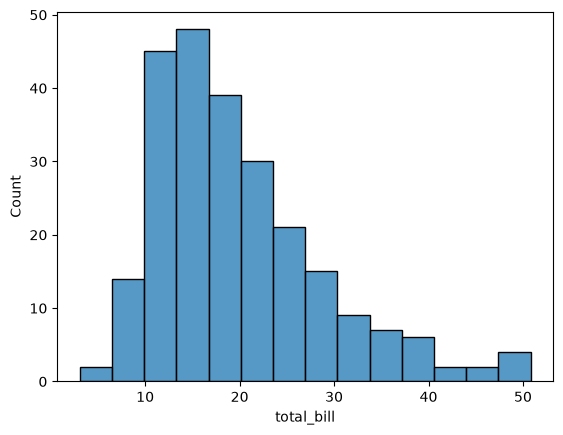

In [15]:
# plotting univariate histogram

sns.histplot(data=tips,x='total_bill')

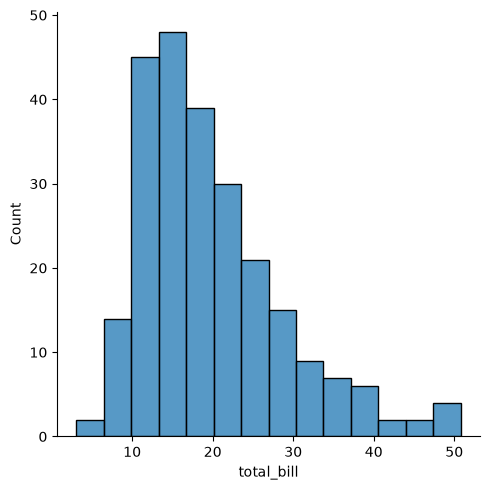

In [16]:
sns.displot(data=tips, x='total_bill', kind='hist')

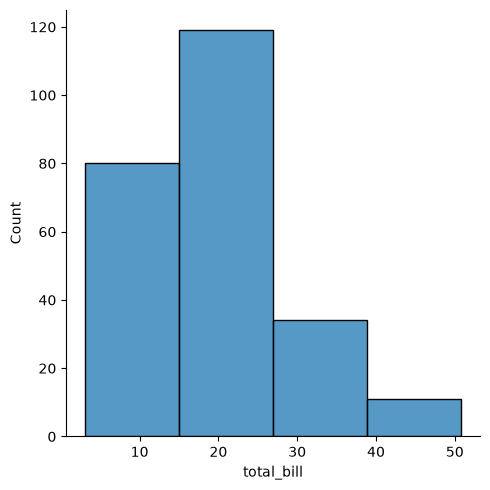

In [17]:
# bins parameter

sns.displot(data=tips, x='total_bill', kind='hist', bins=4)

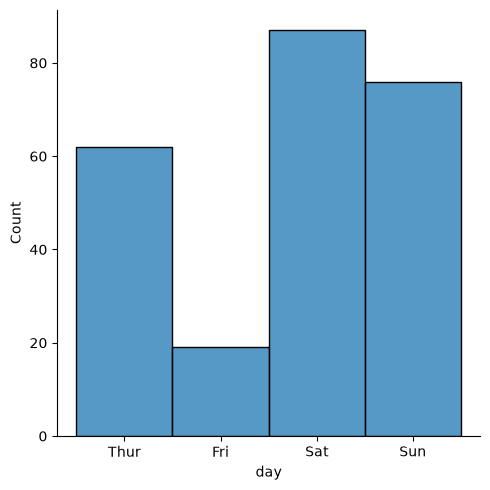

In [18]:
# It's also possible to visualize the distribution of a categorical variable using the logic of histogram
# Discrete bins are automatically set for categorical variable

# countplot
sns.displot(data=tips, x='day', kind='hist')

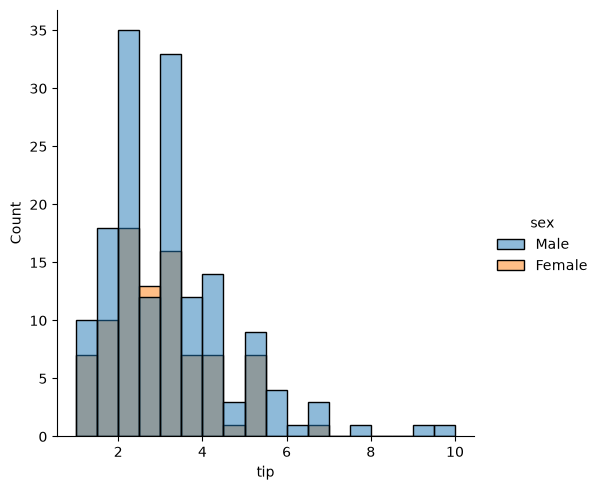

In [19]:
# hue parameter

sns.displot(data=tips,x='tip',kind='hist',hue='sex')

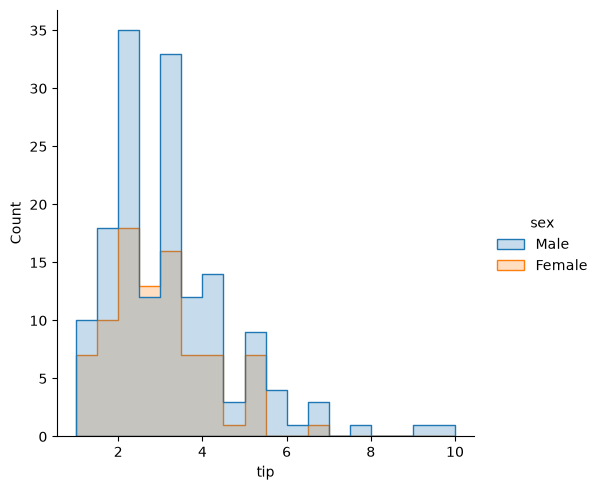

In [20]:
# element -> step

sns.displot(data=tips, x='tip', kind='hist', hue='sex', element ='step')

In [21]:
titanic = sns.load_dataset('titanic')

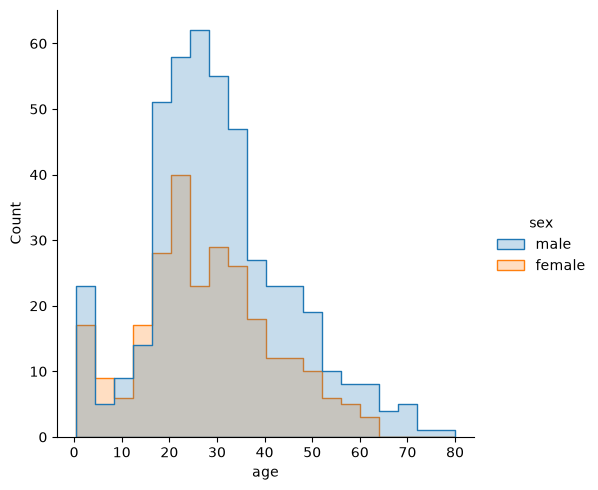

In [22]:
sns.displot(data=titanic,x='age',element='step',hue='sex')

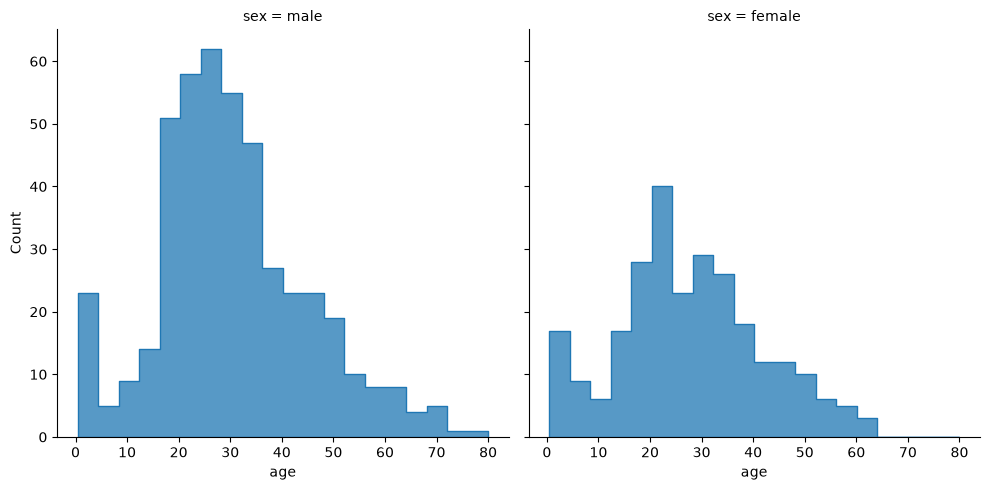

In [23]:
# faceting using col and row -> not work on histplot function
sns.displot(data=titanic,x='age',element='step',col='sex')

<Axes: xlabel='total_bill', ylabel='Density'>

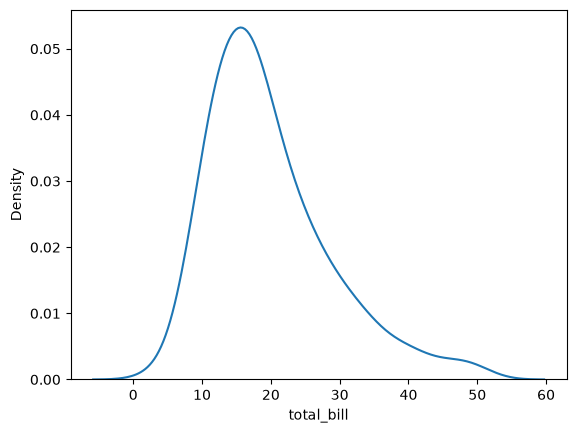

In [24]:
# kdeplot
# Rather than using discrete bins, a KDE plot smooths the observations with a Gaussian kernel, producing a continuous density estimate

sns.kdeplot(data=tips,x='total_bill')

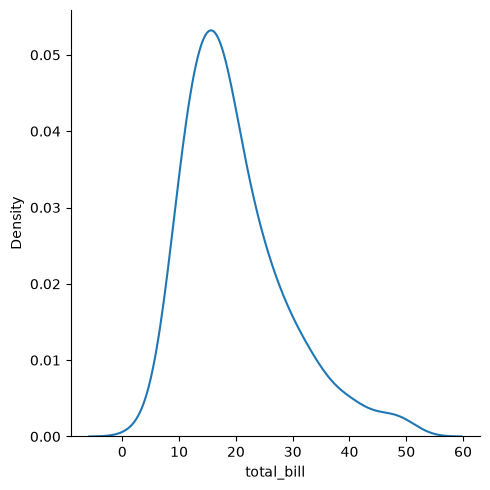

In [25]:
sns.displot(data=tips, kind='kde',x='total_bill')

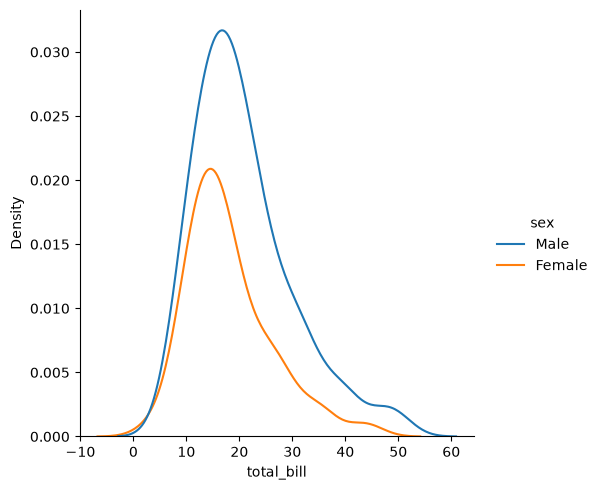

In [26]:
# hue -> fill
sns.displot(data=tips, kind='kde',x='total_bill', hue='sex')

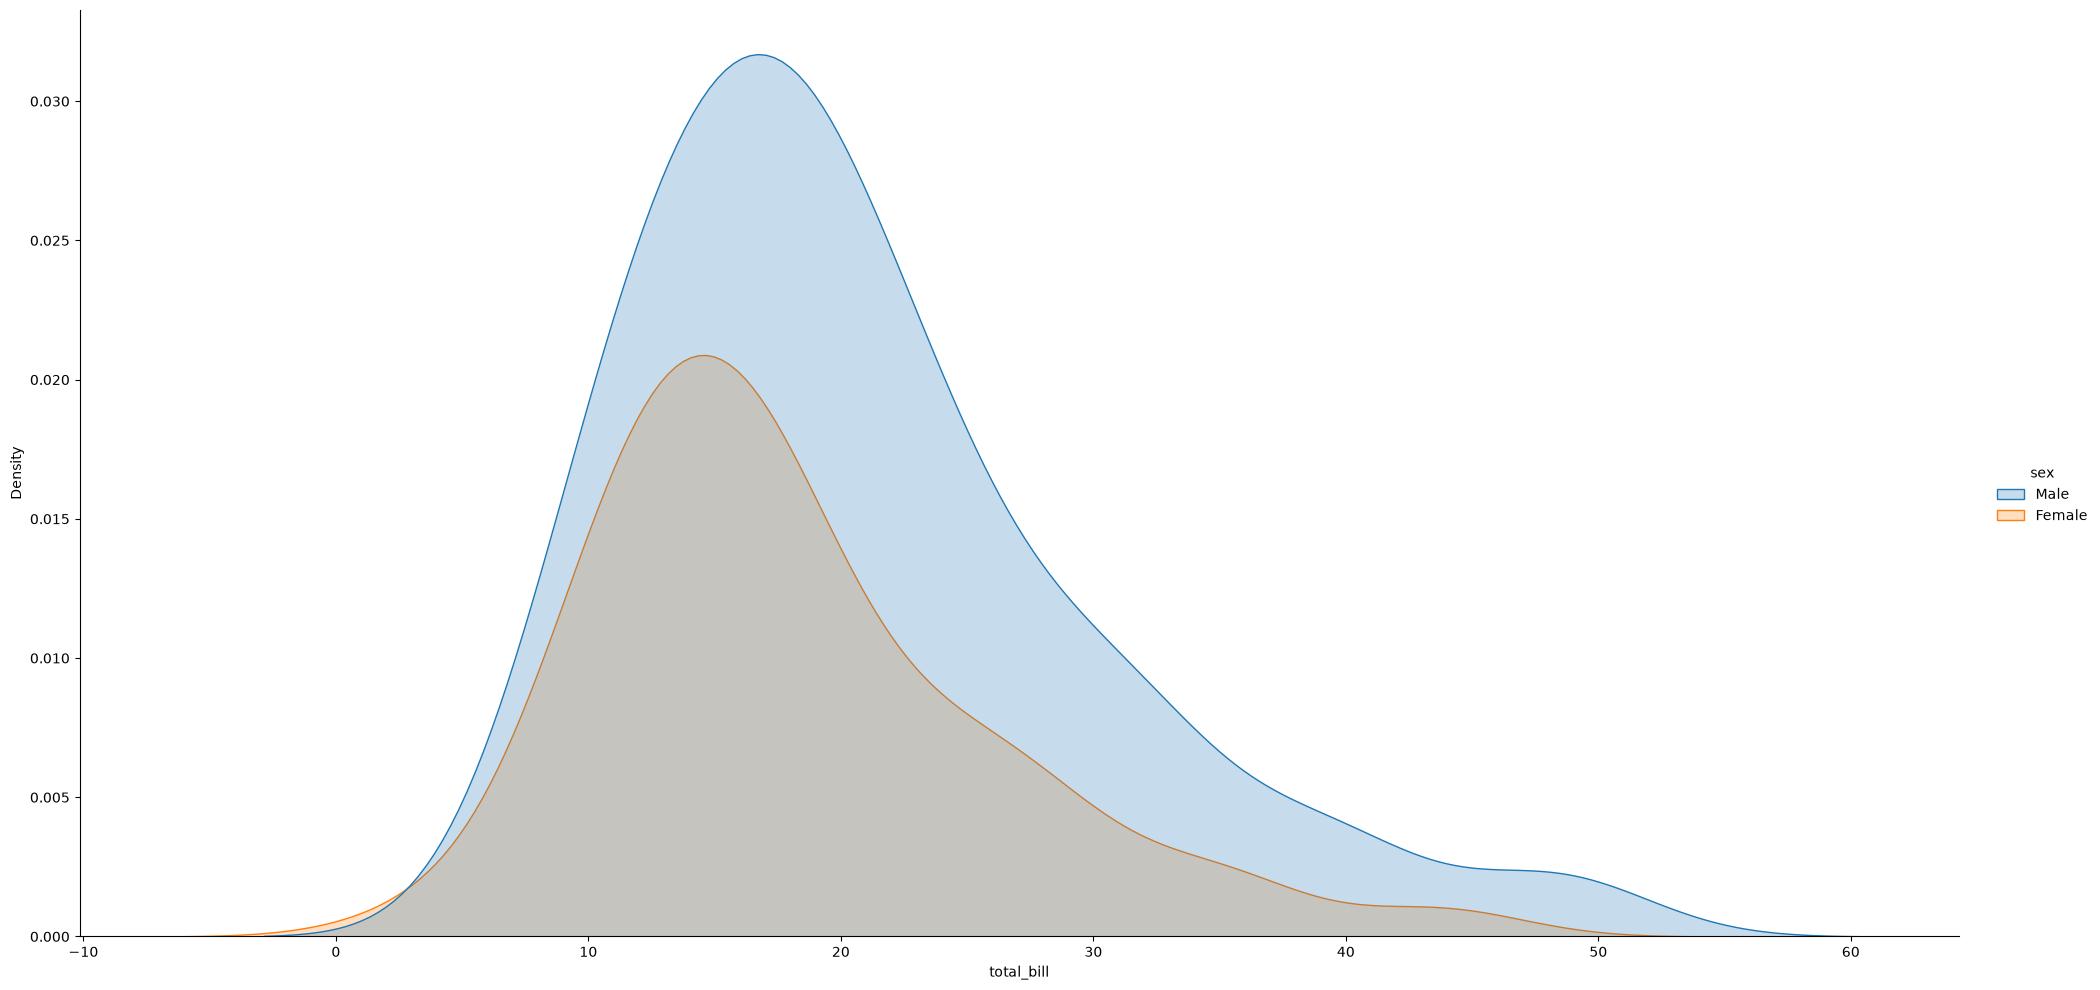

<Axes: xlabel='total_bill', ylabel='Density'>

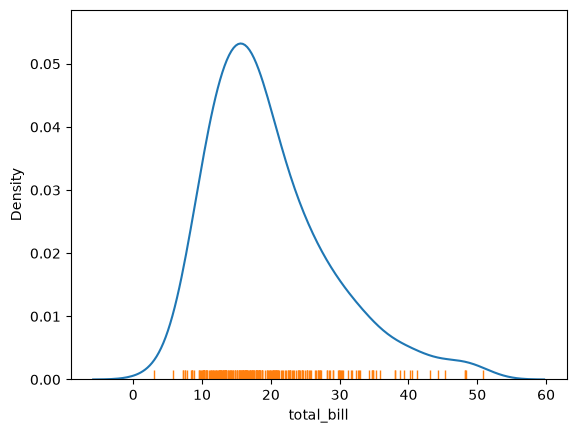

In [28]:
# Rugplot

# Plot marginal distributions by drawing ticks along the x and y axes.

# This function is intended to complement other plots by showing the location of individual observations in an unobtrusive way.

sns.kdeplot(data=tips,x='total_bill')
sns.rugplot(data=tips,x='total_bill')

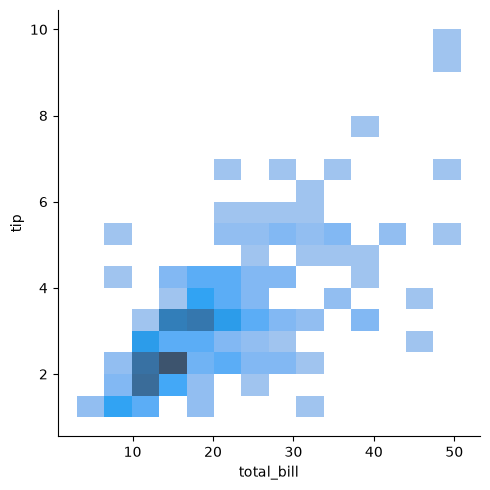

In [29]:
# Bivariate histogram
# A bivariate histogram bins the data within rectangles that tile the plot 
# and then shows the count of observations within each rectangle with the fill color

# sns.histplot(data=tips, x='total_bill', y='tip')

sns.displot(data=tips, x='total_bill', y='tip')

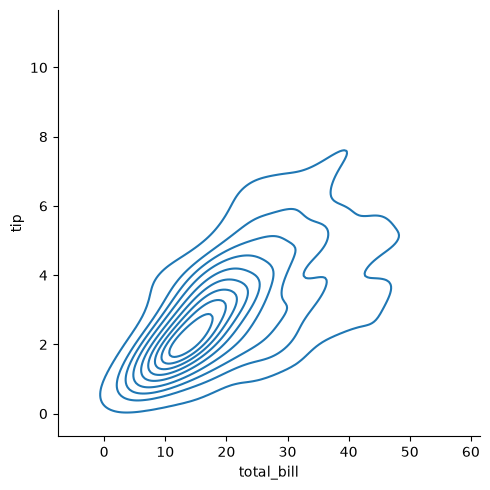

In [30]:
# Bivariate Kdeplot
# a bivariate KDE plot smoothes the (x, y) observations with a 2D Gaussian
sns.displot(data=tips, x='total_bill', y='tip', kind='kde')

### 3. Matrix Plot

- Heatmap
- Clustermap

<Axes: xlabel='year', ylabel='country'>

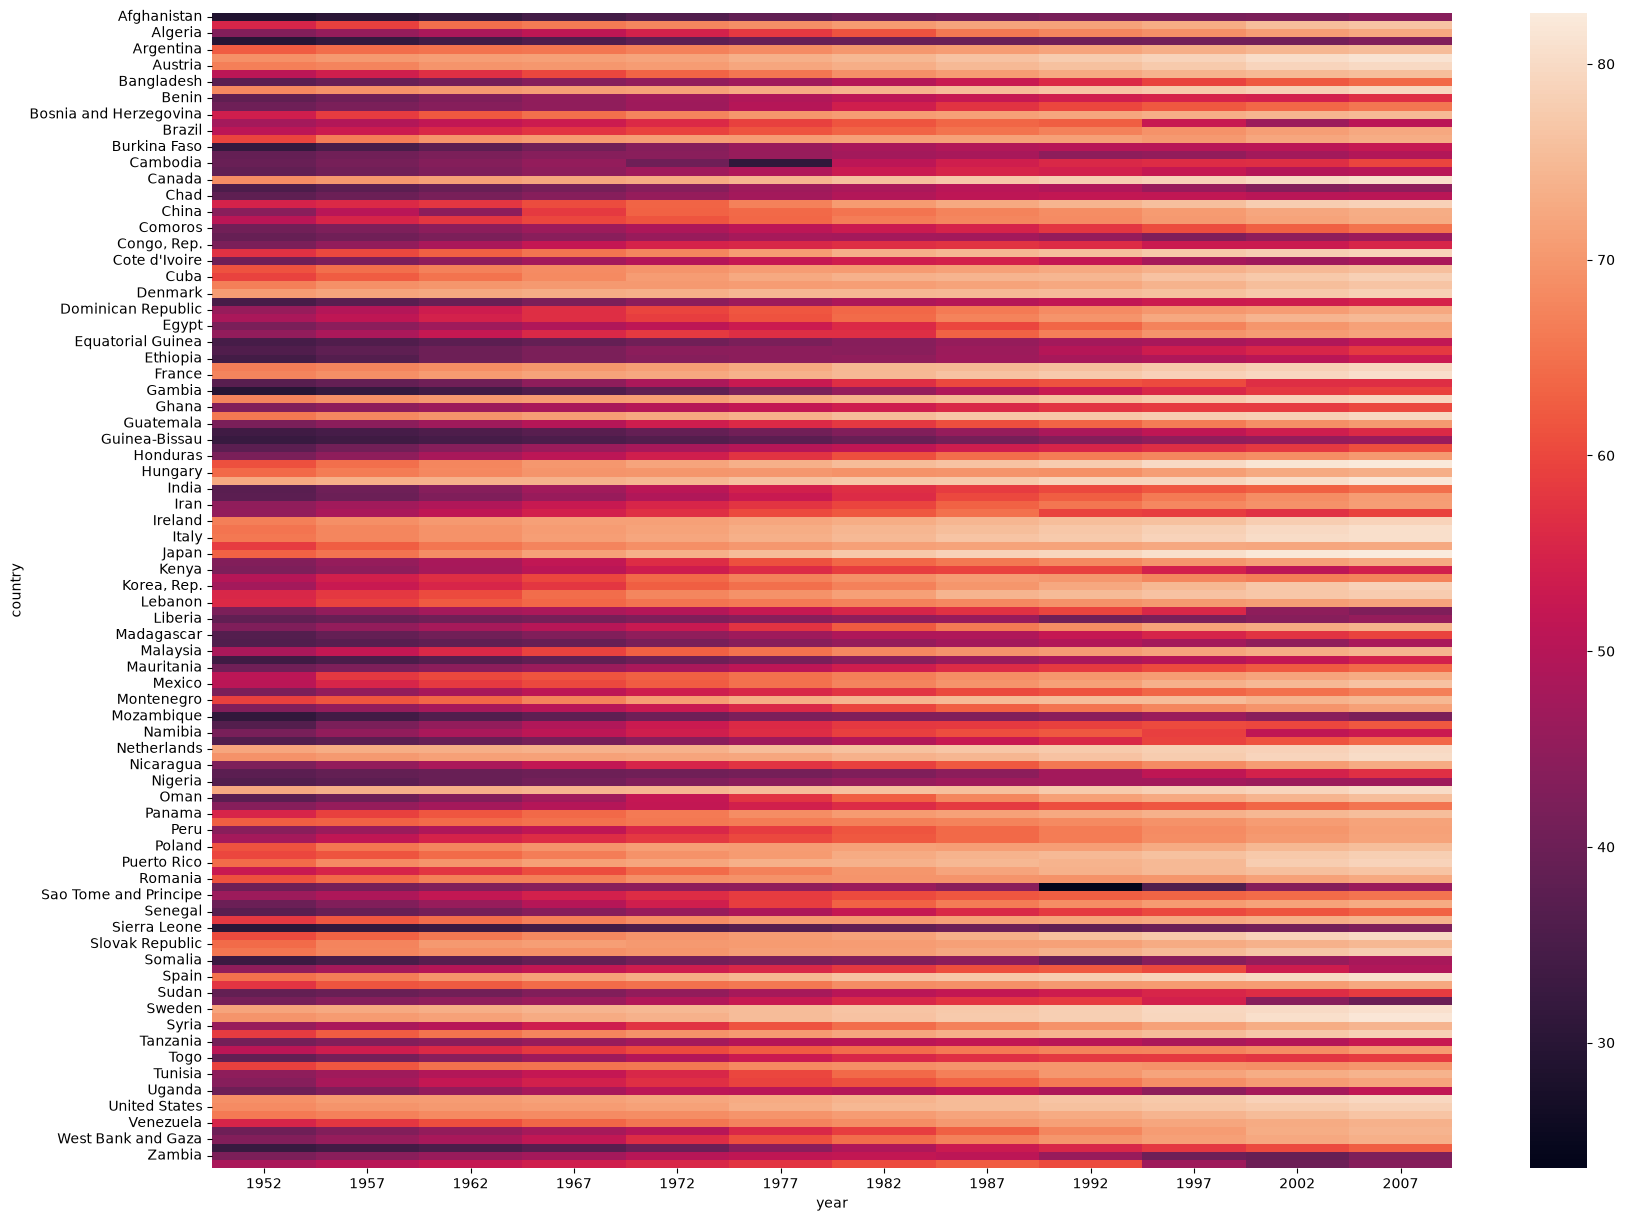

In [31]:
# Heatmap -> axes level
# no figure level function

# plot rectangular data ar a color encoded matrix
temp_df = gap.pivot(index='country',columns='year', values='lifeExp')
plt.figure(figsize=(20,15))
sns.heatmap(data=temp_df)

<Axes: xlabel='year', ylabel='country'>

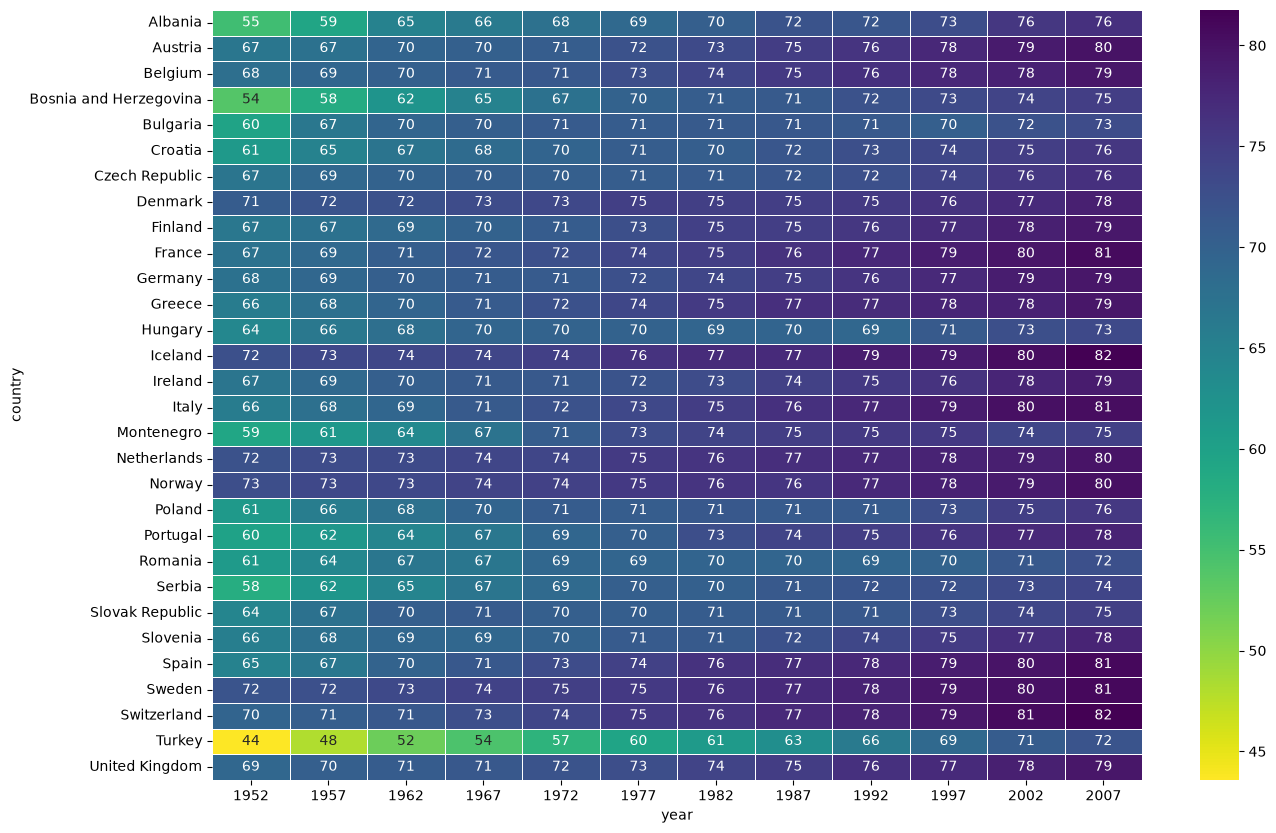

In [32]:
# annot -> linewidth -> cmap
temp_df1 = gap[gap['continent']=='Europe'].pivot(index='country',columns='year', values='lifeExp')

plt.figure(figsize=(15,10))
sns.heatmap(temp_df1,annot=True,linewidths=0.5,cmap='viridis_r')

In [33]:
# Clustermap

# Plot a matrix dataset as a hierarchically-clustered heatmap.

# This function requires scipy to be available.

iris = px.data.iris()
iris

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica,3
146,6.3,2.5,5.0,1.9,virginica,3
147,6.5,3.0,5.2,2.0,virginica,3
148,6.2,3.4,5.4,2.3,virginica,3


In [34]:
import scipy
print(scipy.__version__)

1.17.1


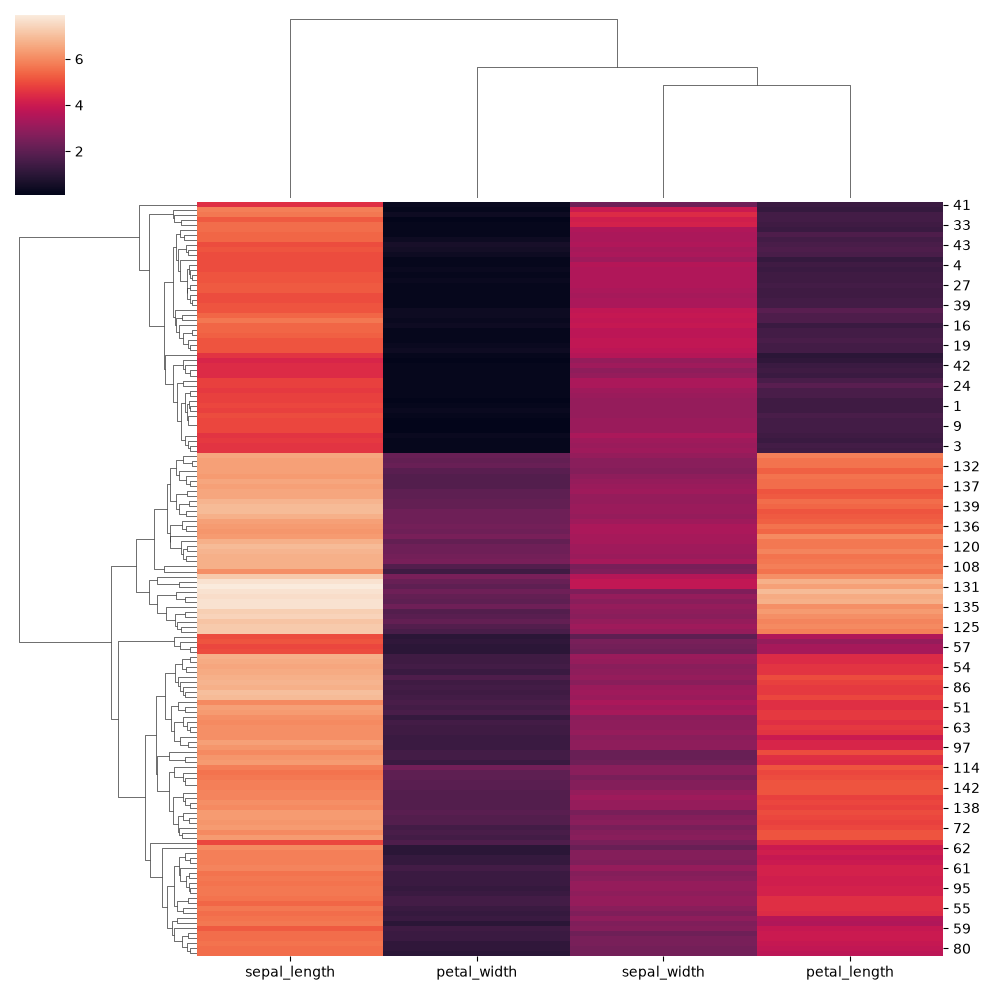

In [36]:
sns.clustermap(iris.iloc[:,[0,1,2,3]])